# Session 1 — Backprop + MLP from Scratch (XOR)

Full theory writeup with ASCII diagrams: `session1_theory.md`.

This notebook builds a tiny neural net **twice**:
1. Raw numpy — forward pass, backward pass (chain rule), weight updates all written by hand.
2. PyTorch — same architecture, but autograd + optimizer do steps 3 and 4 for us.

Task: learn XOR — the classic example a single neuron (no hidden layer) cannot solve.

In [1]:
import sys
sys.path.append("../src")  # modules (data.py, mlp_numpy.py, mlp_pytorch.py) live in src/

import numpy as np
import matplotlib.pyplot as plt

from data import get_xor_data

X, y = get_xor_data()
print("X =\n", X)
print("y =\n", y)

X =
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
y =
 [[0.]
 [1.]
 [1.]
 [0.]]


## 1. Numpy MLP — fully from scratch

Architecture: 2 inputs -> hidden layer (sigmoid) -> 1 output (sigmoid).

Code lives in `mlp_numpy.py` (`NumpyMLP` class) so it's reusable from both this notebook and the Streamlit app — open that file to read the forward/backward math line by line.

In [2]:
from mlp_numpy import NumpyMLP

numpy_model = NumpyMLP(input_size=2, hidden_size=4, output_size=1)

epochs = 5000
learning_rate = 0.5
numpy_losses = []

for epoch in range(epochs):
    loss = numpy_model.train_step(X, y, learning_rate)
    numpy_losses.append(loss)
    if epoch % 500 == 0:
        print(f"epoch {epoch:5d}  loss {loss:.4f}")

print(f"epoch {epochs:5d}  loss {numpy_losses[-1]:.4f}")

epoch     0  loss 0.2551
epoch   500  loss 0.2485
epoch  1000  loss 0.2416
epoch  1500  loss 0.2177
epoch  2000  loss 0.1848
epoch  2500  loss 0.1572
epoch  3000  loss 0.1104
epoch  3500  loss 0.0520
epoch  4000  loss 0.0256
epoch  4500  loss 0.0152
epoch  5000  loss 0.0103


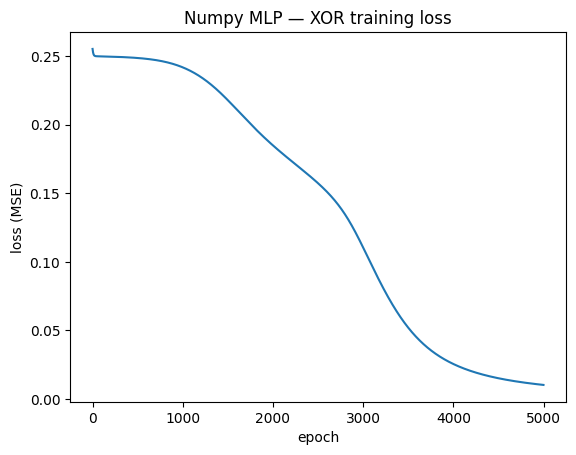

In [3]:
plt.plot(numpy_losses)
plt.xlabel("epoch")
plt.ylabel("loss (MSE)")
plt.title("Numpy MLP — XOR training loss")
plt.show()

In [4]:
print("Final predictions (numpy model):")
predictions = numpy_model.forward(X)
for inputs, target, pred in zip(X, y, predictions):
    print(f"  input={inputs} target={target[0]:.0f} predicted={pred[0]:.3f}")

Final predictions (numpy model):
  input=[0. 0.] target=0 predicted=0.080
  input=[0. 1.] target=1 predicted=0.905
  input=[1. 0.] target=1 predicted=0.902
  input=[1. 1.] target=0 predicted=0.128


## 2. PyTorch MLP — same architecture, autograd does the math

Compare this loop to the numpy one above:
- `loss.backward()` replaces our hand-written `backward()` method.
- `optimizer.step()` replaces our hand-written weight update lines.

Same math, same result — PyTorch just automates it.

In [5]:
import torch
import torch.nn as nn

from mlp_pytorch import TorchMLP

X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

torch_model = TorchMLP(input_size=2, hidden_size=4, output_size=1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(torch_model.parameters(), lr=0.5)

torch_losses = []

for epoch in range(epochs):
    prediction = torch_model(X_t)
    loss = loss_fn(prediction, y_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    torch_losses.append(loss.item())
    if epoch % 500 == 0:
        print(f"epoch {epoch:5d}  loss {loss.item():.4f}")

print(f"epoch {epochs:5d}  loss {torch_losses[-1]:.4f}")

epoch     0  loss 0.2507
epoch   500  loss 0.2479
epoch  1000  loss 0.2169
epoch  1500  loss 0.1523
epoch  2000  loss 0.0349
epoch  2500  loss 0.0117
epoch  3000  loss 0.0064
epoch  3500  loss 0.0042
epoch  4000  loss 0.0031
epoch  4500  loss 0.0025
epoch  5000  loss 0.0020


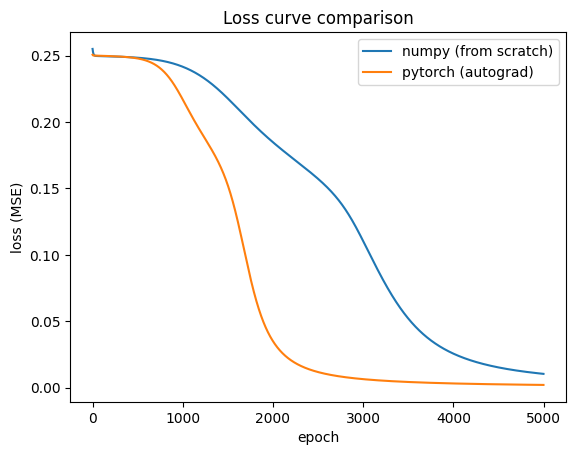

In [6]:
plt.plot(numpy_losses, label="numpy (from scratch)")
plt.plot(torch_losses, label="pytorch (autograd)")
plt.xlabel("epoch")
plt.ylabel("loss (MSE)")
plt.title("Loss curve comparison")
plt.legend()
plt.show()

In [7]:
print("Final predictions (pytorch model):")
with torch.no_grad():
    predictions = torch_model(X_t)
for inputs, target, pred in zip(X_t, y_t, predictions):
    print(f"  input={inputs.tolist()} target={target.item():.0f} predicted={pred.item():.3f}")

Final predictions (pytorch model):
  input=[0.0, 0.0] target=0 predicted=0.041
  input=[0.0, 1.0] target=1 predicted=0.954
  input=[1.0, 0.0] target=1 predicted=0.954
  input=[1.0, 1.0] target=0 predicted=0.047


## Wrap-up

Both models should converge to near-0 loss and correctly predict all 4 XOR cases.

Try the interactive version: `streamlit run app.py` — play with hidden layer size, learning rate, epochs, and see the decision boundary change live.

Next session: CNN internals (convolution math) — see `ROADMAP.md`.